In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [67]:
df = pd.read_csv("covid_19.csv")

df.tail()


,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
233,Argentina,South-America,46010234.0,2024-06-30,2024-06-30T16:15:10+00:00,10128845,9997258.0,130841.0,35716069.0
234,Netherlands,Europe,17211447.0,2024-06-30,2024-06-30T16:15:10+00:00,8635786,8612599.0,22992.0,25984435.0
235,Mexico,North-America,131562772.0,2024-06-30,2024-06-30T16:15:10+00:00,7702809,6899865.0,334958.0,20013810.0
236,Iran,Asia,86022837.0,2024-06-30,2024-06-30T16:15:10+00:00,7627186,NaN,146811.0,57320267.0
237,Indonesia,Asia,279134505.0,2024-06-30,2024-06-30T16:15:10+00:00,6829221,6647104.0,162063.0,114158919.0


In [68]:
df.describe()

,population,Cases,Recovered,Deaths,Tests
count,2.290000e+02,2.380000e+02,1.900000e+02,2.330000e+02,2.130000e+02
mean,3.469404e+07,8.883449e+06,1.006214e+07,9.026621e+04,3.298829e+07
std,1.386374e+08,5.193031e+07,5.555519e+07,5.163434e+05,1.198779e+08
min,7.990000e+02,9.000000e+00,2.000000e+00,1.000000e+00,7.850000e+03
25%,4.454310e+05,2.741875e+04,2.197250e+04,2.250000e+02,3.478150e+05
50%,5.797805e+06,2.320425e+05,2.351455e+05,2.570000e+03,2.226216e+06
75%,2.210284e+07,1.565481e+06,2.078212e+06,1.805700e+04,1.346373e+07
max,1.448471e+09,7.047539e+08,6.756198e+08,7.010681e+06,1.186852e+09


In [53]:
# Convert date column
df['day'] = pd.to_datetime(df['day'])

# Fill missing values
df[['Cases','Recovered','Deaths','Tests']] = df[['Cases','Recovered','Deaths','Tests']].fillna(0)

# Remove aggregate rows (continents, 'All')
df = df[~df['country'].isin(['All','Asia','Europe','Africa','Oceania','North-America','South-America'])]

In [54]:
# -------------------------------
# Part 2: Exploratory Data Analysis
# -------------------------------

# Top 10 countries by cases
top_cases = df.groupby('country')['Cases'].sum().nlargest(10)

# Top 10 countries by deaths
top_deaths = df.groupby('country')['Deaths'].sum().nlargest(10)

# Continent-wise aggregation
continent_cases = df.groupby('continent')['Cases'].sum()
continent_deaths = df.groupby('continent')['Deaths'].sum()


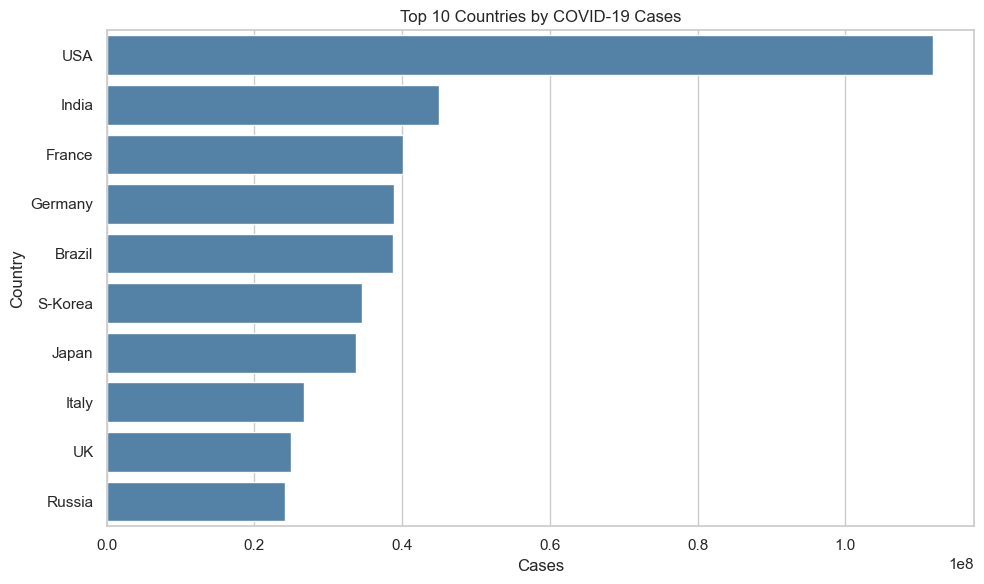

In [55]:
# Bar chart - Top 10 countries by cases
plt.figure(figsize=(10,6))
sns.barplot(x=top_cases.values, y=top_cases.index, color="steelblue")
plt.title("Top 10 Countries by COVID-19 Cases")
plt.xlabel("Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

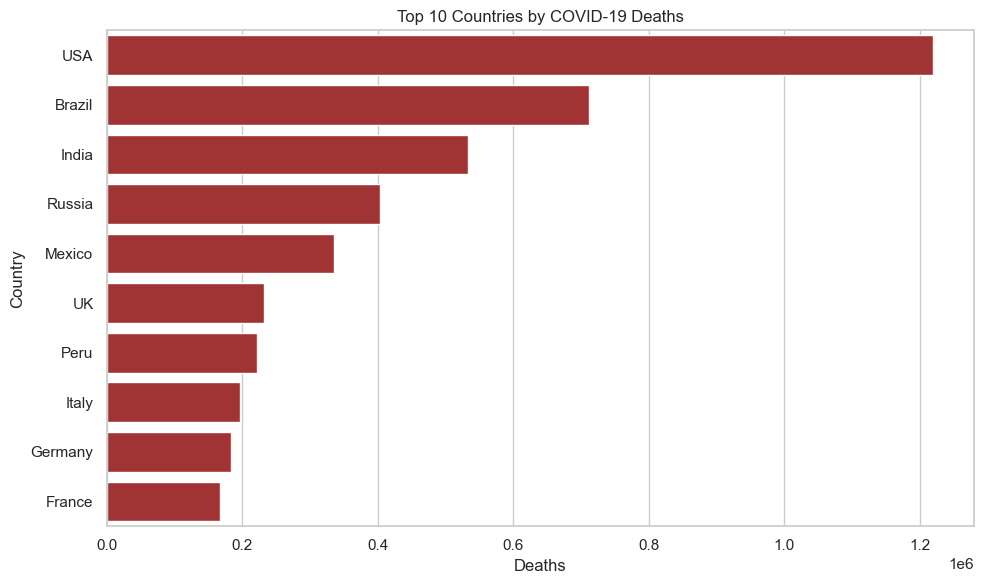

In [56]:
# Bar chart - Top 10 countries by deaths
plt.figure(figsize=(10,6))
sns.barplot(x=top_deaths.values, y=top_deaths.index, color="firebrick")
plt.title("Top 10 Countries by COVID-19 Deaths")
plt.xlabel("Deaths")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


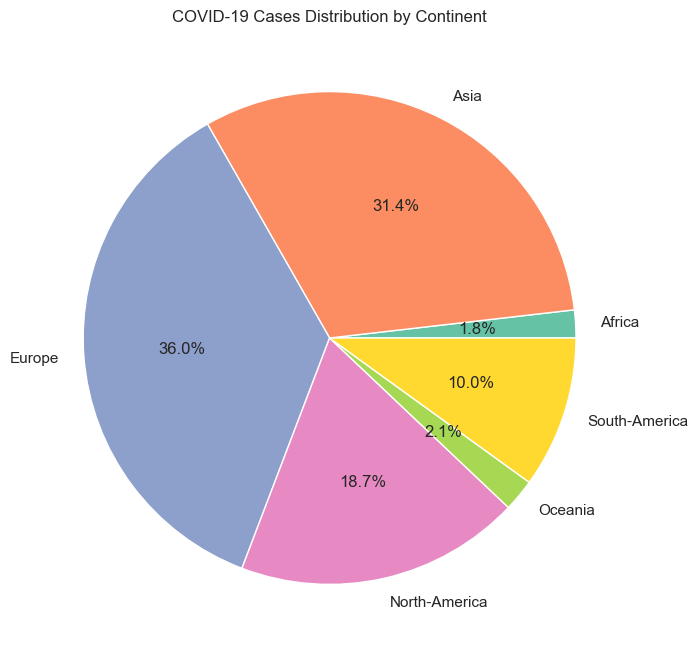

In [57]:
# Pie chart - Continent-wise cases
plt.figure(figsize=(8,8))
plt.pie(continent_cases, labels=continent_cases.index, autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title("COVID-19 Cases Distribution by Continent")
plt.show()


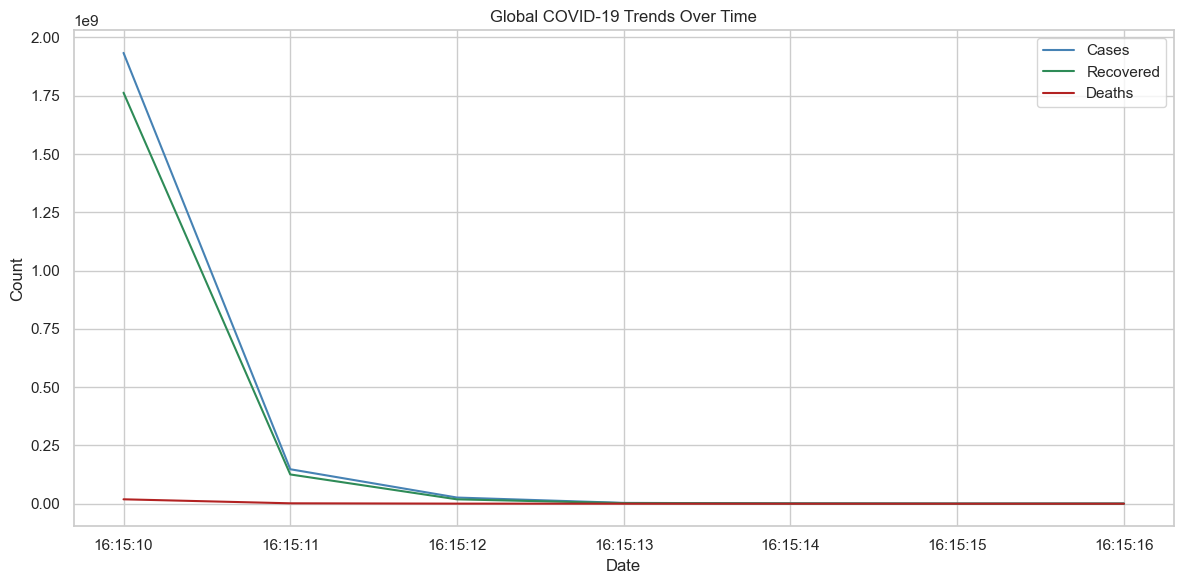

In [63]:
# -------------------------------
# Global Trends Line Chart
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("covid_19.csv")

# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# Group by time (instead of day)
global_trends = df.groupby('time')[['Cases','Recovered','Deaths']].sum()

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(global_trends.index, global_trends['Cases'], label="Cases", color="steelblue")
plt.plot(global_trends.index, global_trends['Recovered'], label="Recovered", color="seagreen")
plt.plot(global_trends.index, global_trends['Deaths'], label="Deaths", color="firebrick")

plt.title("Global COVID-19 Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


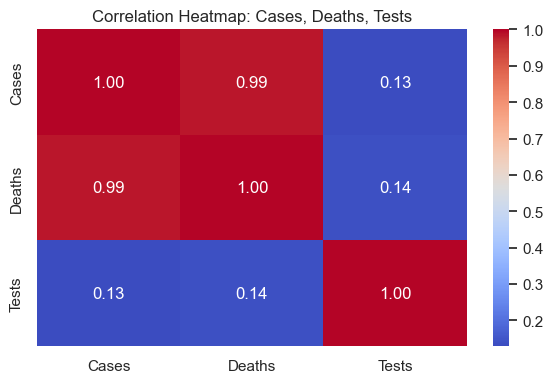

In [61]:
# Heatmap Correlation
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("covid_19.csv")

# Fill missing values with 0
df[['Cases','Recovered','Deaths','Tests']] = df[['Cases','Recovered','Deaths','Tests']].fillna(0)

# Correlation matrix for selected columns
corr_matrix = df[['Cases','Deaths','Tests']].corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Cases, Deaths, Tests")
plt.tight_layout()
plt.show()


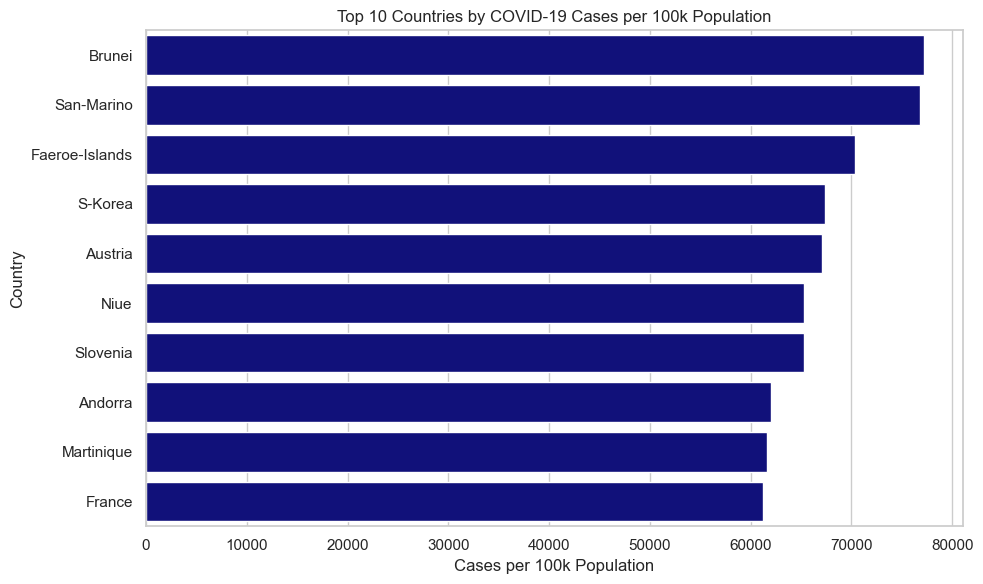

In [62]:
# Per Capita Analysis
# -------------------------------

# Remove rows with missing population
df = df[df['population'].notnull()]

# Calculate cases per 100k population
df['Cases_per_100k'] = (df['Cases'] / df['population']) * 100000

# Top 10 countries by cases per 100k
top_per_capita = df[['country','Cases_per_100k']].sort_values(by='Cases_per_100k', ascending=False).head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x='Cases_per_100k', y='country', data=top_per_capita, color="darkblue")
plt.title("Top 10 Countries by COVID-19 Cases per 100k Population")
plt.xlabel("Cases per 100k Population")
plt.ylabel("Country")
plt.tight_layout()
plt.show()